In [108]:
import pandas as pd
import numpy as np
from math import isnan
import multiprocessing as mp
import json
import os
from protocols import utils, functions, graphs
from catomatic.RegressionCatalogue import RegressionBuilder
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportion_confint



%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Apply the catalogues to Determine their Performance 

Here we test the catalogues built in 02-grid-search, 02b-grid-search, and by the WHO to the Training Set, Validation Set, and The Entire Dataset.

This is parallelised using multiprocessing implemented for Unix/MacOS, and will likely have to be adapted for Windows.

In [109]:
# the path to the CRyPTIC v3.1.0 data tables (including the DST_MEASUREMENTS_+.pkl which has DST for the validation samples appended)
cryptic_tables_path = 'data/cryptic-tables-v3.4.0/'

#read in genes relevant to each drug
with open('data/drug_to_genes.json', 'r') as f:
    drug_genes = json.load(f)

# whether to run the processes which take a long time
run_long_processes = False

# number of cores
n_cores = 9

who_drugs = list(pd.read_csv('data/who2_drugs.csv').drug)

In [110]:
def process_performance(args):
    #apply the specified catalogues to the specified dataset (training, validation, or all)
    #parallelises across number of cores specified above
    
    drug, genes, catalogues, validation, FRS, dataset = args
    results = []

    if drug in who_drugs:
        
        mutations = functions.prep_mutations(
            'data/mutations-v3.4.0/', 
            genes, 
            version='v3.4.0', 
            mut_path=cryptic_tables_path+'MUTATIONS.parquet', 
            var_path=cryptic_tables_path+'VARIANTS.parquet',
            train=False
        )

        if dataset != 'all':
            phenotypes = functions.prep_phenotypes(
                drug,
                cryptic_tables_path+'DST_MEASUREMENTS.parquet',
                cryptic_tables_path+'WGS_SAMPLES.parquet',
                version='v3.4.0',
                validation= validation
            )
        else:
            train_phenotypes = functions.prep_phenotypes(
            drug,
            cryptic_tables_path+'DST_MEASUREMENTS.parquet',
            cryptic_tables_path+'WGS_SAMPLES.parquet',
            version='v3.4.0',
            validation= False
            )

            val_phenotypes = functions.prep_phenotypes(
            drug,
            cryptic_tables_path+'DST_MEASUREMENTS.parquet',
            cryptic_tables_path+'WGS_SAMPLES.parquet',
            version='v3.4.0',
            validation= True
            )
            phenotypes = pd.concat([train_phenotypes, val_phenotypes])

        phenotypes.set_index('UNIQUEID', inplace=True)
        mutations.set_index('UNIQUEID', inplace=True)
        all_data = phenotypes.join(mutations[mutations.FRS >= FRS], how='left')
        all_data.reset_index(inplace=True)

        if len(all_data)>0:

            for cat_name in catalogues:

                cm, cov, sens, spec, sens2, spec2 = utils.piezo_predict(iso_df=all_data, drug=drug, catalogue_file=catalogues[cat_name])

                TP = cm[0, 0]
                FN = cm[0, 1]
                TN = cm[1, 1]
                FP = cm[1, 0]
                UP = cm[0, 2]
                UN = cm[1, 2]

                # Sensitivity CI
                sens_low, sens_high = proportion_confint(
                    count=TP, 
                    nobs=TP+FN, 
                    alpha=0.05, 
                    method="wilson"
                )

                # Specificity CI
                spec_low, spec_high = proportion_confint(
                    count=TN, 
                    nobs=TN+FP, 
                    alpha=0.05, 
                    method="wilson"
                )

                dpr_low, dpr_high = proportion_confint(
                    count = TN + FN + TP + FP,
                    nobs = TN + FN + TP + FP + UP + UN,
                    alpha=0.05,
                    method='wilson'
                )

                results.append({
                    'DRUG': drug,
                    'catalogue': cat_name,
                    'SENSITIVITY': sens,
                    'SPECIFICITY': spec,
                    'COVERAGE': cov,
                    'SENSITIVITY2': sens2,
                    'SPECIFICITY2': spec2,
                    'SENSITIVITY_LOW': sens_low,
                    'SENSITIVITY_HIGH': sens_high,
                    'SPECIFICITY_LOW': spec_low,
                    'SPECIFICITY_HIGH': spec_high,
                    'DPR_LOW': dpr_low,
                    'DPR_HIGH': dpr_high,
                    'TP': TP,
                    'FN': FN,
                    'TN': TN,
                    'FP': FP,
                    'UP': UP,
                    'UN': UN
                })
    return results

def parallel_performance_evaluation(drug_genes, catalogues,  validation, frs, dataset=None):
    tasks = [(drug, data['genes'], catalogues, validation, frs, dataset) for drug, data in drug_genes.items()]
    
    # Works on Mac/Linux
    ctx = mp.get_context("fork") 
    
    # Don't use more workers than tasks
    num_workers = min(n_cores, len(tasks))  

    # Run in parallel
    with ctx.Pool(num_workers) as pool:
        all_results = list(pool.imap(process_performance, tasks))
    
    results_df = pd.DataFrame([item for sublist in all_results for item in sublist])

    return results_df



## WHOv1 vs WHOv2 vs published applied to The Training Set (FRS 0.75)

In [111]:
#performance on whov1 for whov1 and whov2, at FRS 0.75 (even playing field)
if run_long_processes:

    catalogues = {
        'WHOv1': 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv',
        'WHOv2': 'catalogues/whov2/NC_000962.3_WHO-UCN-TB-2023.5_v2.0_GARC1_RFUS.csv',
    }

    results_who_train = parallel_performance_evaluation(drug_genes, catalogues, validation=False, frs=0.75)
    results_who_train.to_csv('results/performance/whov1_whov2_training.csv')
results_who_train = pd.read_csv('results/performance/whov1_whov2_training.csv')
results_who_train

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,SENSITIVITY_LOW,SENSITIVITY_HIGH,SPECIFICITY_LOW,SPECIFICITY_HIGH,DPR_LOW,DPR_HIGH,TP,FN,TN,FP,UP,UN
0,0,RIF,WHOv1,0.948812,0.978710,0.979368,0.946468,0.979311,9.445146e-01,0.952793,0.976858,0.980417,0.977868,0.980768,10343,558,24778,539,27,736
1,1,RIF,WHOv2,0.949078,0.978616,0.977583,0.946559,0.979273,9.447901e-01,0.953049,0.976758,0.980329,0.976024,0.979043,10344,555,24713,540,29,800
2,2,INH,WHOv1,0.922796,0.990468,0.966442,0.888011,0.990765,9.181090e-01,0.927236,0.989121,0.991650,0.964563,0.968226,12132,1015,22549,217,515,732
3,3,INH,WHOv2,0.930054,0.989618,0.963079,0.895403,0.989999,9.255684e-01,0.934288,0.988212,0.990858,0.961113,0.964948,12233,920,22400,235,509,863
4,4,EMB,WHOv1,0.934951,0.918535,0.904159,0.871493,0.926777,9.278867e-01,0.941368,0.915151,0.921796,0.901008,0.907220,4815,335,23926,2122,375,2932
5,5,EMB,WHOv2,0.915330,0.926225,0.942124,0.847240,0.930262,9.073853e-01,0.922652,0.923069,0.929261,0.939611,0.944539,4681,433,25373,2021,411,1586
6,6,PZA,WHOv1,0.813303,0.976701,0.982037,0.774295,0.976999,7.990513e-01,0.826762,0.974412,0.978789,0.980183,0.983720,2470,567,17858,426,153,237
7,7,PZA,WHOv2,0.815080,0.974772,0.985215,0.786207,0.975055,8.009721e-01,0.828401,0.972399,0.976946,0.983521,0.986737,2508,569,17851,462,113,208
8,8,LEV,WHOv1,0.865376,0.971948,0.927558,0.835766,0.974225,8.501723e-01,0.879255,0.968288,0.975196,0.922736,0.932102,1832,285,8558,247,75,778
9,9,LEV,WHOv2,0.866511,0.971075,0.930021,0.843978,0.973390,8.514238e-01,0.880281,0.967366,0.974374,0.925272,0.934490,1850,285,8561,255,57,767


In [112]:
pvals = utils.generate_pvals(results_who_train, comparisons=[('WHOv1', 'WHOv2')])
pvals.to_csv('results/performance/p_vals_whov1_whov2_training.csv')
pvals[(pvals.sens_p_value<0.05)|(pvals.spec_p_value<0.05)|(pvals.dpr_p_value<0.05)]

,DRUG,Comparison,sens_p_value,spec_p_value,dpr_p_value,sens2_p_value,spec2_p_value
1,INH,WHOv1 > WHOv2,2.418400e-02,3.614788e-01,1.289152e-02,4.927022e-02,3.949083e-01
2,EMB,WHOv1 > WHOv2,1.583674e-04,8.915443e-04,3.321165e-78,2.455816e-04,1.034343e-01
3,PZA,WHOv1 > WHOv2,8.582377e-01,2.304872e-01,9.076699e-03,2.505860e-01,2.213950e-01
5,MXF,WHOv1 > WHOv2,9.683267e-01,8.685472e-01,2.575370e-04,5.122246e-01,6.735312e-01
6,BDQ,WHOv1 > WHOv2,4.773937e-12,8.149873e-29,2.383728e-72,7.235749e-11,4.551188e-28
8,CFZ,WHOv1 > WHOv2,5.867263e-10,9.478300e-26,1.067259e-98,2.780552e-09,5.849056e-25
10,AMI,WHOv1 > WHOv2,5.724945e-01,9.509562e-01,4.149865e-02,1.000000e+00,1.000000e+00
13,KAN,WHOv1 > WHOv2,9.519106e-01,9.186039e-01,1.014926e-02,1.000000e+00,1.000000e+00


Plot WHOv1 on the training set vs WHOv1 published performance:

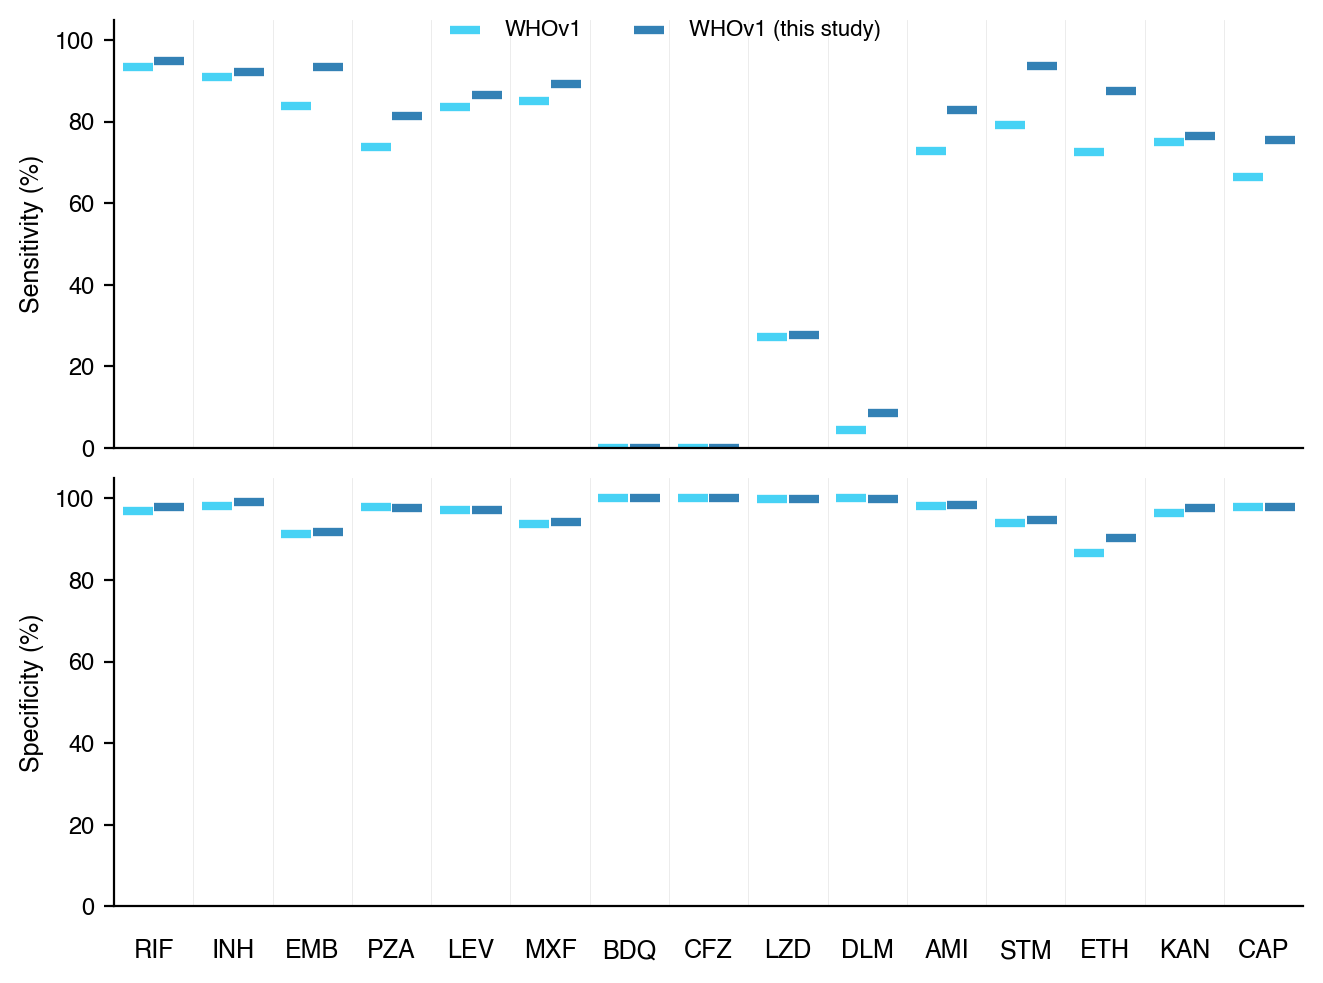

In [113]:
#read in published WHO results
who_results = pd.read_csv('data/WHO2-Annex1-table.csv')
who_results = who_results.iloc[::-1]
who_results = who_results[who_results.FRS==0.75]

#read in WHO results applied to our training set
who_train = pd.read_csv('results/performance/whov1_whov2_training.csv')
who_train.sort_values(['DRUG','catalogue'], inplace=True)

graphs.plot_scatter_who(who_train[who_train.catalogue=='WHOv1'], who_results[who_results.catalogue=="WHO1"],'figs/performance/scatter-training-who1-who2.pdf', who_drugs, show_graph=True)

Can also plot WHOv1 vs WHOv2 on training set.

## WHOv1 vs WHOv2 applied to The Validation Set (FRS 0.75) vs published

In [114]:
#performance on whov1 for whov1 and whov2, at FRS 0.75 (even playing field)
if run_long_processes:

    catalogues = {
        'WHOv1': 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv',
        'WHOv2': 'catalogues/whov2/NC_000962.3_WHO-UCN-TB-2023.5_v2.0_GARC1_RFUS.csv',
    }

    results_who_val = parallel_performance_evaluation(drug_genes, catalogues, validation=True, frs=0.75)
    results_who_val.to_csv('results/performance/whov1_whov2_validation.csv')
results_who_val = pd.read_csv('results/performance/whov1_whov2_validation.csv')
results_who_val[:6]

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,SENSITIVITY_LOW,SENSITIVITY_HIGH,SPECIFICITY_LOW,SPECIFICITY_HIGH,DPR_LOW,DPR_HIGH,TP,FN,TN,FP,UP,UN
0,0,RIF,WHOv1,0.937661,0.973241,0.986762,0.934158,0.973746,0.930006,0.944529,0.969212,0.976755,0.984503,0.988696,4001,266,6874,189,16,136
1,1,RIF,WHOv2,0.937925,0.973157,0.985020,0.934859,0.973746,0.930285,0.944776,0.969116,0.976682,0.982630,0.987085,4004,265,6852,189,14,158
2,2,INH,WHOv1,0.915288,0.982128,0.966960,0.878852,0.982616,0.907262,0.922679,0.978450,0.985188,0.963515,0.970089,4592,425,5880,107,208,168
3,3,INH,WHOv2,0.921058,0.980375,0.956854,0.886507,0.981316,0.913280,0.928193,0.976497,0.983625,0.952964,0.960436,4632,397,5745,115,196,295
4,4,EMB,WHOv1,0.890899,0.829196,0.891131,0.823414,0.850090,0.875997,0.904207,0.817778,0.840038,0.883639,0.898197,1674,205,3641,750,154,612
5,5,EMB,WHOv2,0.865476,0.840035,0.920836,0.810133,0.853688,0.849407,0.880072,0.829129,0.850370,0.914295,0.926917,1647,256,3844,732,130,427


In [115]:
pvals = utils.generate_pvals(results_who_val, comparisons=[('WHOv1', 'WHOv2')])
pvals.to_csv('results/performance/p_vals_whov1_whov2_validation.csv')
pvals[(pvals.sens2_p_value<0.05)|(pvals.spec2_p_value<0.05)]

,DRUG,Comparison,sens_p_value,spec_p_value,dpr_p_value,sens2_p_value,spec2_p_value
3,PZA,WHOv1 > WHOv2,6.709696e-01,3.247553e-01,9.331881e-05,8.303229e-03,3.053715e-01
6,BDQ,WHOv1 > WHOv2,7.527292e-142,1.243152e-09,8.699228e-38,1.639323e-123,1.792264e-09
8,CFZ,WHOv1 > WHOv2,1.255003e-04,2.812592e-11,6.319391e-21,1.980762e-04,4.774186e-11
9,DLM,WHOv1 > WHOv2,5.175151e-02,3.173543e-01,5.558529e-01,4.065168e-02,3.172671e-01


Plot WHOv1 on the Validation set vs published values:

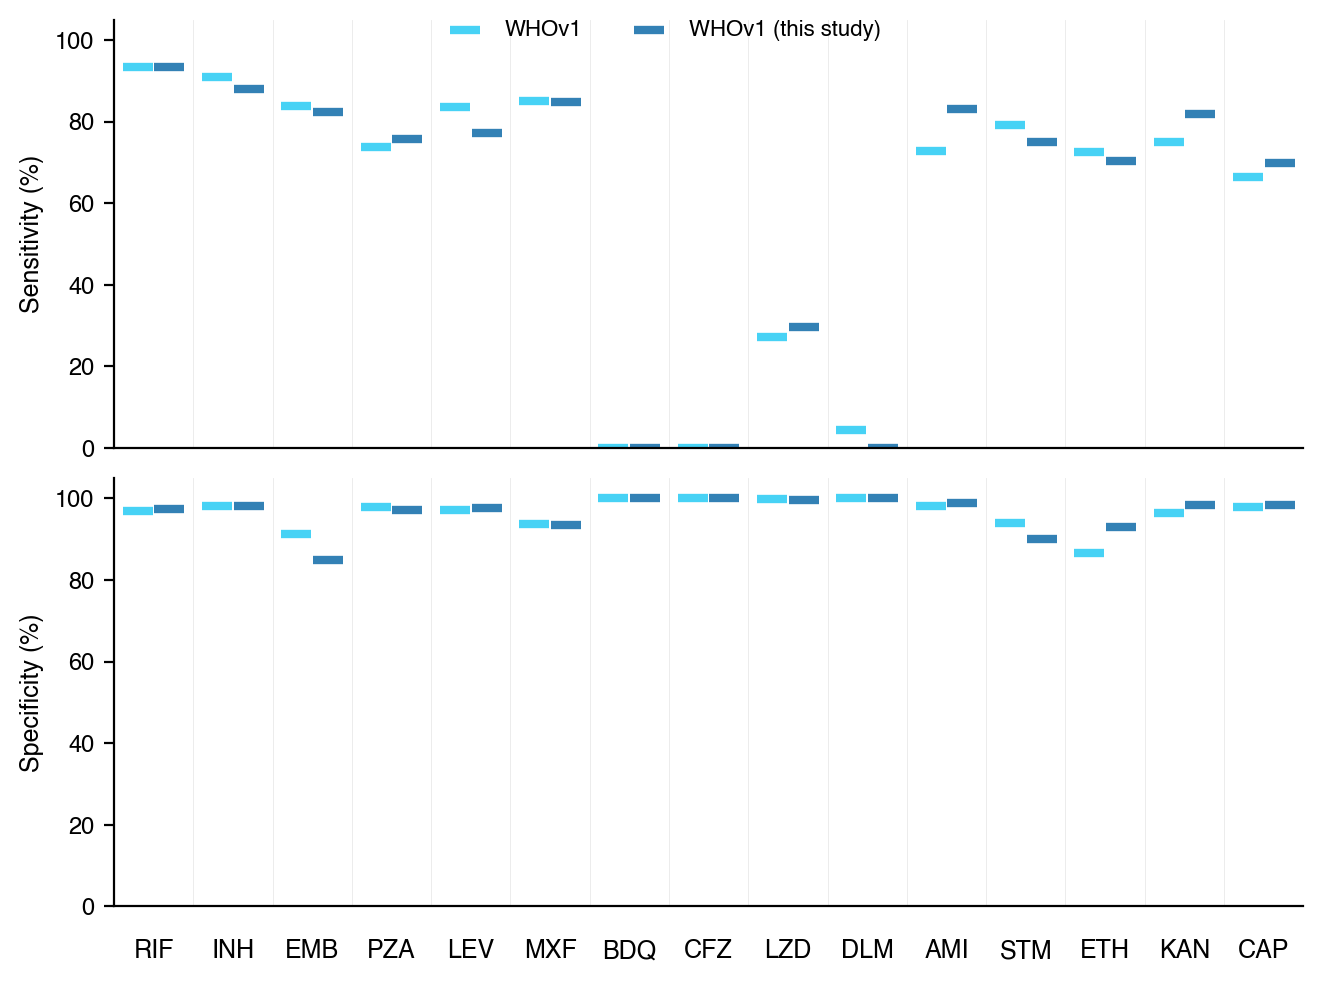

In [116]:
#read in WHO results applied to our validation set
who_val = pd.read_csv('results/performance/whov1_whov2_validation.csv')
who_val.sort_values(['DRUG','catalogue'], inplace=True)
who_val = who_val[['catalogue', 'DRUG', 'SENSITIVITY2', 'SPECIFICITY2']].rename(columns={'SENSITIVITY2':'SENSITIVITY', 'SPECIFICITY2':'SPECIFICITY'})

graphs.plot_scatter_who(who_val[who_val.catalogue=='WHOv1'], who_results[who_results.catalogue=="WHO1"],'figs/performance/scatter-validation-who1-who2.pdf', who_drugs, show_graph=True)

## Compare WHOv1 on training set vs WHOv1 on validation set (FRS 0.75)

In [117]:
whov1_train = results_who_train[results_who_train['catalogue'] == 'WHOv1'].copy()
whov1_train['catalogue'] = 'WHOv1_train'
whov1_val = results_who_val[results_who_val['catalogue'] == 'WHOv1'].copy()
whov1_val['catalogue'] = 'WHOv1_val'
whov1_train_val = pd.concat([whov1_train, whov1_val], ignore_index=True)

pvals = utils.generate_pvals(whov1_train_val, comparisons=[('WHOv1_train', 'WHOv1_val')])
pvals.to_csv('results/performance/p_vals_whov1_whov2_validation.csv')
pvals[(pvals.spec2_p_value<0.05)|(pvals.sens2_p_value<0.05)]

/Users/dylanadlard/miniforge3/envs/cryptic-catalogues-25/lib/python3.13/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


,DRUG,Comparison,sens_p_value,spec_p_value,dpr_p_value,sens2_p_value,spec2_p_value
0,RIF,WHOv1_train > WHOv1_val,6.441898e-03,6.115643e-03,3.671454e-07,3.227190e-03,4.288637e-03
1,INH,WHOv1_train > WHOv1_val,9.400810e-02,5.320958e-08,7.883045e-01,7.703174e-02,4.379849e-08
2,EMB,WHOv1_train > WHOv1_val,8.381124e-10,2.599544e-78,8.110234e-04,1.044035e-07,1.682123e-72
3,PZA,WHOv1_train > WHOv1_val,6.573633e-02,1.314515e-02,1.609019e-40,1.739804e-01,2.235239e-02
4,LEV,WHOv1_train > WHOv1_val,7.448852e-03,2.760229e-01,3.970001e-01,1.113764e-03,3.159438e-01
5,MXF,WHOv1_train > WHOv1_val,7.197659e-01,1.604340e-03,8.866306e-01,1.466918e-01,1.098569e-03
10,AMI,WHOv1_train > WHOv1_val,2.913421e-01,2.615325e-02,1.873414e-09,1.203476e-01,4.012633e-02
11,STM,WHOv1_train > WHOv1_val,3.707222e-02,2.576321e-28,1.021235e-38,9.179047e-08,1.416878e-20
12,ETH,WHOv1_train > WHOv1_val,6.315824e-03,1.732707e-02,1.235406e-03,1.765617e-01,4.925691e-03
13,KAN,WHOv1_train > WHOv1_val,9.982891e-05,1.166008e-03,5.592601e-02,1.886962e-05,1.360356e-03


In [118]:
utils.compute_metric_differences(whov1_train_val, pvals[(pvals.Comparison == 'WHOv1_train > WHOv1_val') &((pvals.sens2_p_value < 0.05) |(pvals.spec2_p_value < 0.05))])

,DRUG,Comparison,SENSITIVITY_diff,SPECIFICITY_diff,COVERAGE_diff,SENSITIVITY2_diff,SPECIFICITY2_diff
0,RIF,WHOv1_train > WHOv1_val,0.011151,0.005469,-0.007394,0.012309,0.005565
1,INH,WHOv1_train > WHOv1_val,0.007508,0.008340,-0.000517,0.009159,0.008149
2,EMB,WHOv1_train > WHOv1_val,0.044052,0.089339,0.013027,0.048080,0.076687
3,PZA,WHOv1_train > WHOv1_val,-0.021667,0.006084,0.028476,0.016921,0.005484
4,LEV,WHOv1_train > WHOv1_val,0.049049,-0.003856,-0.004227,0.063234,-0.003284
5,MXF,WHOv1_train > WHOv1_val,0.004480,0.011959,0.000552,0.019573,0.011252
6,AMI,WHOv1_train > WHOv1_val,-0.017780,-0.003801,-0.020558,-0.027249,-0.003266
7,STM,WHOv1_train > WHOv1_val,0.016601,0.075414,0.084151,0.062278,0.052830
8,ETH,WHOv1_train > WHOv1_val,0.036678,-0.013951,0.018607,0.021874,-0.014281
9,KAN,WHOv1_train > WHOv1_val,-0.063232,-0.006909,-0.005870,-0.070676,-0.006417


## WHOv1 vs WHOv2 vs catomatic on training set (FRS 0.1)

In [119]:
#performance on training set (ie cryptic-v1.0)
if run_long_processes:

    catalogues = {
        'WHOv1': 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv',
        'WHOv2': 'catalogues/whov2/NC_000962.3_WHO-UCN-TB-2023.5_v2.0_GARC1_RFUS.csv',
        'MTBC-CRyPTICv1.1.1-2025.8': "catalogues/MTBC-CRyPTICv1.1.1-2025.8.csv",
    }
    results_train = parallel_performance_evaluation(drug_genes, catalogues, validation=False, frs=0.1)
    results_train.to_csv('results/performance/whov1_whov2_cat1_training.csv')
results_train = pd.read_csv('results/performance/whov1_whov2_cat1_training.csv')
results_train[:6]

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,SENSITIVITY_LOW,SENSITIVITY_HIGH,SPECIFICITY_LOW,SPECIFICITY_HIGH,DPR_LOW,DPR_HIGH,TP,FN,TN,FP,UP,UN
0,0,RIF,WHOv1,0.962029,0.975051,0.977664,0.959828,0.975819,0.958275,0.965457,0.973054,0.976904,0.976108,0.979121,10489,414,24622,630,25,801
1,1,RIF,WHOv2,0.962385,0.974947,0.975825,0.959919,0.975780,0.958648,0.965797,0.972944,0.976806,0.974210,0.977342,10490,410,24556,631,28,866
2,2,RIF,MTBC-CRyPTICv1.1.1-2025.8,0.961417,0.985268,0.971120,0.943997,0.985760,0.957604,0.964899,0.983704,0.986684,0.969364,0.972779,10316,414,24812,371,198,870
3,3,INH,WHOv1,0.934681,0.989184,0.957239,0.896574,0.989659,0.930322,0.938786,0.987745,0.990455,0.955134,0.959249,12249,856,22223,243,557,1032
4,4,INH,WHOv2,0.941997,0.988247,0.952987,0.904626,0.988850,0.937866,0.945869,0.986746,0.989580,0.950788,0.955093,12359,761,22031,262,542,1205
5,5,INH,MTBC-CRyPTICv1.1.1-2025.8,0.945534,0.987895,0.956970,0.917435,0.988510,0.941540,0.949270,0.986374,0.989249,0.954859,0.958986,12534,722,22035,270,406,1193


In [120]:
pvals_train = utils.generate_pvals(results_train, comparisons=[('WHOv1', 'WHOv2'), ('WHOv1', 'MTBC-CRyPTICv1.1.1-2025.8'), ('WHOv2', 'MTBC-CRyPTICv1.1.1-2025.8')])
pvals_train.to_csv('results/performance/p_vals_whov1_whov2_cat1_training.csv')
pvals_train[(pvals_train.sens_p_value<0.05)|(pvals_train.spec_p_value<0.05)|(pvals_train.dpr_p_value<0.05)][:6]

,DRUG,Comparison,sens_p_value,spec_p_value,dpr_p_value,sens2_p_value,spec2_p_value
1,RIF,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,0.814475,1.952547e-16,1.768522e-08,4.513518e-08,1.385397e-16
2,RIF,WHOv2 > MTBC-CRyPTICv1.1.1-2025.8,0.709801,1.094017e-16,6.850523e-05,3.721459e-08,1.096454e-16
3,INH,WHOv1 > WHOv2,0.013793,3.484198e-01,5.124704e-03,2.613914e-02,3.952870e-01
4,INH,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,0.000204,2.002301e-01,8.563405e-01,2.909949e-09,2.306683e-01
5,INH,WHOv2 > MTBC-CRyPTICv1.1.1-2025.8,0.212445,7.318333e-01,8.839633e-03,2.003325e-04,7.272215e-01
6,EMB,WHOv1 > WHOv2,0.000137,6.644878e-04,2.998522e-43,2.141060e-04,1.061122e-01


In [121]:
results_training = pd.read_csv('results/performance/whov1_whov2_cat1_training.csv')
results_training.DRUG = results_training.DRUG.astype('category')
results_training.DRUG = results_training.DRUG.cat.set_categories(who_drugs)
results_training.sort_values(['DRUG','catalogue'], inplace=True, ascending=False)
results_training = results_training.iloc[::-1]
results_training = results_training[results_training.DRUG.isin(who_results.drug.values)]
results_training[:6]

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,SENSITIVITY_LOW,SENSITIVITY_HIGH,SPECIFICITY_LOW,SPECIFICITY_HIGH,DPR_LOW,DPR_HIGH,TP,FN,TN,FP,UP,UN
5,5,INH,MTBC-CRyPTICv1.1.1-2025.8,0.945534,0.987895,0.956970,0.917435,0.988510,0.941540,0.949270,0.986374,0.989249,0.954859,0.958986,12534,722,22035,270,406,1193
3,3,INH,WHOv1,0.934681,0.989184,0.957239,0.896574,0.989659,0.930322,0.938786,0.987745,0.990455,0.955134,0.959249,12249,856,22223,243,557,1032
4,4,INH,WHOv2,0.941997,0.988247,0.952987,0.904626,0.988850,0.937866,0.945869,0.986746,0.989580,0.950788,0.955093,12359,761,22031,262,542,1205
2,2,RIF,MTBC-CRyPTICv1.1.1-2025.8,0.961417,0.985268,0.971120,0.943997,0.985760,0.957604,0.964899,0.983704,0.986684,0.969364,0.972779,10316,414,24812,371,198,870
0,0,RIF,WHOv1,0.962029,0.975051,0.977664,0.959828,0.975819,0.958275,0.965457,0.973054,0.976904,0.976108,0.979121,10489,414,24622,630,25,801
1,1,RIF,WHOv2,0.962385,0.974947,0.975825,0.959919,0.975780,0.958648,0.965797,0.972944,0.976806,0.974210,0.977342,10490,410,24556,631,28,866


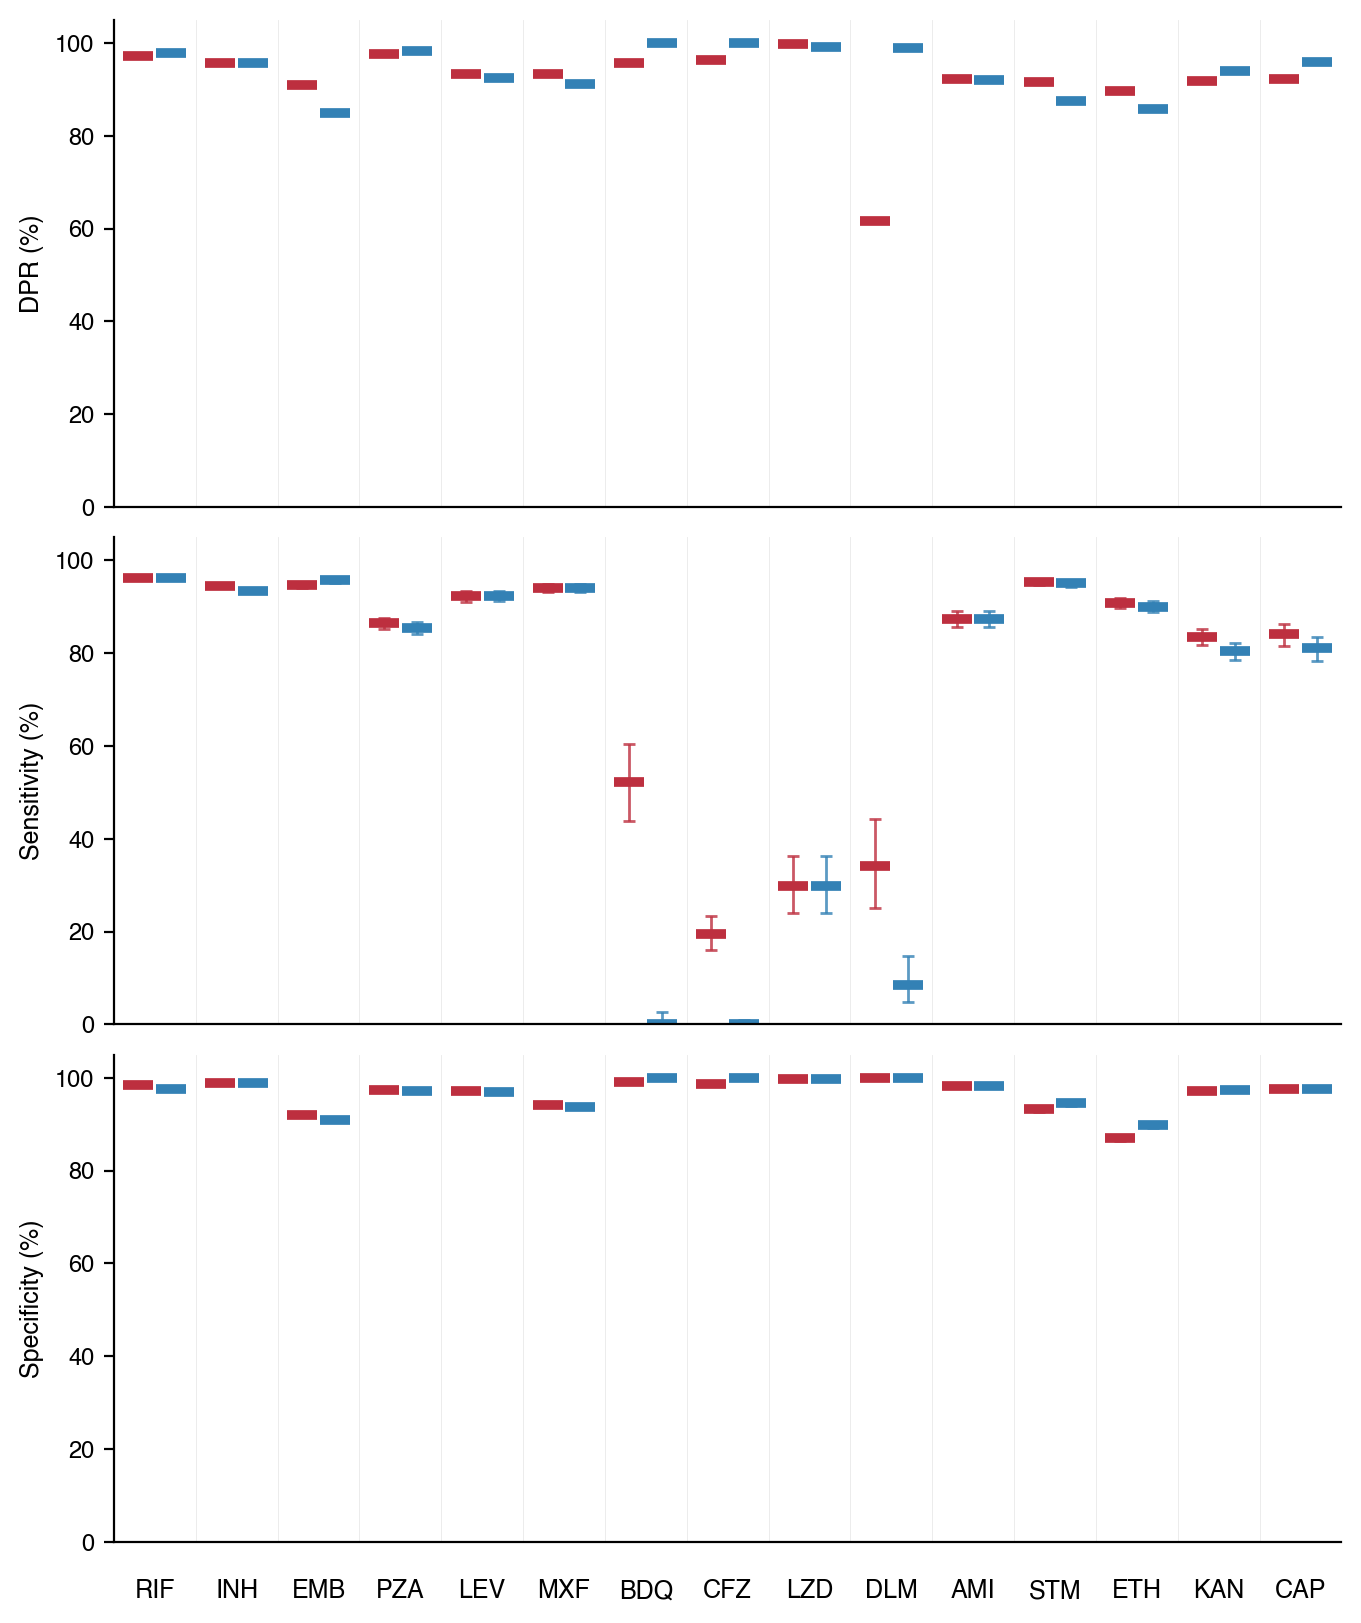

In [122]:
graphs.plot_scatter_catomatic(results_training[results_training.catalogue.isin(['MTBC-CRyPTICv1.1.1-2025.8', 'WHOv1'])], 'figs/performance/scatter-training-who1-cat1.pdf', who_drugs, show_graph=True, figsize=(6.69, 8))

## WHOv1 vs WHOv2 vs catomatic on validation set (FRS 0.1)

In [123]:
#performance on validation set (ie > cryptic-v1.0)
if run_long_processes:

    catalogues = {
        'WHOv1': 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv',
        'WHOv2': 'catalogues/whov2/NC_000962.3_WHO-UCN-TB-2023.5_v2.0_GARC1_RFUS.csv',
        'MTBC-CRyPTICv1.1.1-2025.8': "catalogues/MTBC-CRyPTICv1.1.1-2025.8.csv",
    }
    results_val = parallel_performance_evaluation(drug_genes, catalogues, validation=True, frs=0.1)
    results_val.to_csv('results/performance/whov1_whov2_cat1_validation.csv')
results_val = pd.read_csv('results/performance/whov1_whov2_cat1_validation.csv')
results_val[:10]

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,SENSITIVITY_LOW,SENSITIVITY_HIGH,SPECIFICITY_LOW,SPECIFICITY_HIGH,DPR_LOW,DPR_HIGH,TP,FN,TN,FP,UP,UN
0,0,RIF,WHOv1,0.955504,0.971052,0.985630,0.952603,0.971663,0.948899,0.961289,0.966873,0.974717,0.983285,0.987650,4080,190,6843,204,13,152
1,1,RIF,WHOv2,0.955758,0.970961,0.983888,0.953304,0.971663,0.949172,0.961526,0.966769,0.974637,0.981418,0.986034,4083,189,6821,204,11,174
2,2,RIF,MTBC-CRyPTICv1.1.1-2025.8,0.954480,0.978878,0.975701,0.935092,0.979442,0.947747,0.960382,0.975240,0.981992,0.972722,0.978362,4005,191,6859,148,87,192
3,3,INH,WHOv1,0.936610,0.979374,0.940773,0.893589,0.980829,0.929504,0.943043,0.975357,0.982748,0.936286,0.944963,4669,316,5603,118,240,434
4,4,INH,WHOv2,0.942566,0.977444,0.929965,0.901435,0.979529,0.935768,0.948683,0.973209,0.981022,0.925129,0.934510,4710,287,5460,126,228,569
5,5,INH,MTBC-CRyPTICv1.1.1-2025.8,0.945935,0.976962,0.957030,0.910813,0.978067,0.939339,0.951851,0.972797,0.980503,0.953147,0.960604,4759,272,5725,135,194,295
6,6,EMB,WHOv1,0.934630,0.787945,0.786526,0.850959,0.843894,0.922445,0.945014,0.774447,0.800843,0.776797,0.795943,1730,121,2902,781,182,1320
7,7,EMB,WHOv2,0.916174,0.802129,0.811825,0.838662,0.847691,0.902710,0.927924,0.789248,0.814408,0.802523,0.820787,1705,156,3089,762,172,1152
8,8,EMB,MTBC-CRyPTICv1.1.1-2025.8,0.914621,0.823516,0.886441,0.843089,0.846092,0.901105,0.926440,0.811921,0.834542,0.878816,0.893645,1714,160,3593,770,159,640
9,9,PZA,WHOv1,0.879852,0.953707,0.951579,0.794658,0.955184,0.863130,0.894780,0.947590,0.959141,0.946322,0.956344,1428,195,4862,236,174,168


In [124]:
pvals_val = utils.generate_pvals(results_val, comparisons=[('WHOv1', 'WHOv2'), ('WHOv1', 'MTBC-CRyPTICv1.1.1-2025.8'), ('WHOv2', 'MTBC-CRyPTICv1.1.1-2025.8')])
pvals_val.to_csv('results/performance/p_vals_whov1_whov2_cat1_validation.csv')
#pvals_val[(pvals_val.Comparison == 'WHOv1 > MTBC-CRyPTICv1.1.1-2025.8') &((pvals_val.sens_p_value < 0.05) |(pvals_val.spec_p_value < 0.05) |(pvals_val.dpr_p_value < 0.05))]
pvals_val_who1_cat1 = pvals_val[pvals_val.Comparison=='WHOv1 > MTBC-CRyPTICv1.1.1-2025.8']
pvals_val_who1_cat1[:10]

/Users/dylanadlard/miniforge3/envs/cryptic-catalogues-25/lib/python3.13/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


,DRUG,Comparison,sens_p_value,spec_p_value,dpr_p_value,sens2_p_value,spec2_p_value
1,RIF,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,8.204068e-01,2.989281e-03,4.674336e-08,4.316116e-04,2.511279e-03
4,INH,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,4.713729e-02,3.747109e-01,2.563173e-08,3.037544e-03,2.801706e-01
7,EMB,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,2.077780e-02,5.581446e-05,8.701592e-58,4.857585e-01,7.612416e-01
10,PZA,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,5.605038e-01,1.077095e-01,4.595448e-03,7.401241e-01,7.825168e-02
13,LEV,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,9.003654e-01,4.229548e-01,7.439883e-01,8.545133e-01,4.333193e-01
16,MXF,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,8.230035e-01,3.521050e-01,1.071958e-06,9.356413e-01,6.038716e-01
19,BDQ,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,3.972883e-186,2.053331e-10,1.482810e-148,1.029480e-101,1.067245e-09
22,LZD,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,9.683672e-01,9.947962e-01,9.512480e-02,1.000000e+00,1.000000e+00
25,CFZ,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,2.189066e-06,2.266215e-11,2.257415e-28,4.914133e-06,4.774186e-11
28,DLM,WHOv1 > MTBC-CRyPTICv1.1.1-2025.8,8.451596e-02,NaN,0.000000e+00,1.525554e-01,NaN


In [125]:
diffs = utils.compute_metric_differences(results_val, pvals_val[(pvals_val.Comparison == 'WHOv1 > MTBC-CRyPTICv1.1.1-2025.8')])
diffs = pd.merge(diffs, pvals_val_who1_cat1, on=['DRUG', 'Comparison'])
diffs[['DRUG', 'SENSITIVITY_diff', 'sens_p_value', 'SPECIFICITY_diff', 'spec_p_value', 'COVERAGE_diff', 'dpr_p_value']][:10]

,DRUG,SENSITIVITY_diff,sens_p_value,SPECIFICITY_diff,spec_p_value,COVERAGE_diff,dpr_p_value
0,RIF,0.001023,8.204068e-01,-0.007827,2.989281e-03,0.009929,4.674336e-08
1,INH,-0.009325,4.713729e-02,0.002412,3.747109e-01,-0.016257,2.563173e-08
2,EMB,0.020009,2.077780e-02,-0.035571,5.581446e-05,-0.099915,8.701592e-58
3,PZA,-0.006568,5.605038e-01,-0.006492,1.077095e-01,0.010760,4.595448e-03
4,LEV,0.002502,9.003654e-01,-0.003333,4.229548e-01,-0.002032,7.439883e-01
5,MXF,0.002487,8.230035e-01,-0.004442,3.521050e-01,-0.021607,1.071958e-06
6,BDQ,-0.736196,3.972883e-186,0.011563,2.053331e-10,0.144877,1.482810e-148
7,LZD,0.002201,9.683672e-01,-0.000008,9.947962e-01,-0.002685,9.512480e-02
8,CFZ,-0.191919,2.189066e-06,0.012786,2.266215e-11,0.033501,2.257415e-28
9,DLM,-0.086957,8.451596e-02,0.000000,NaN,0.445464,0.000000e+00


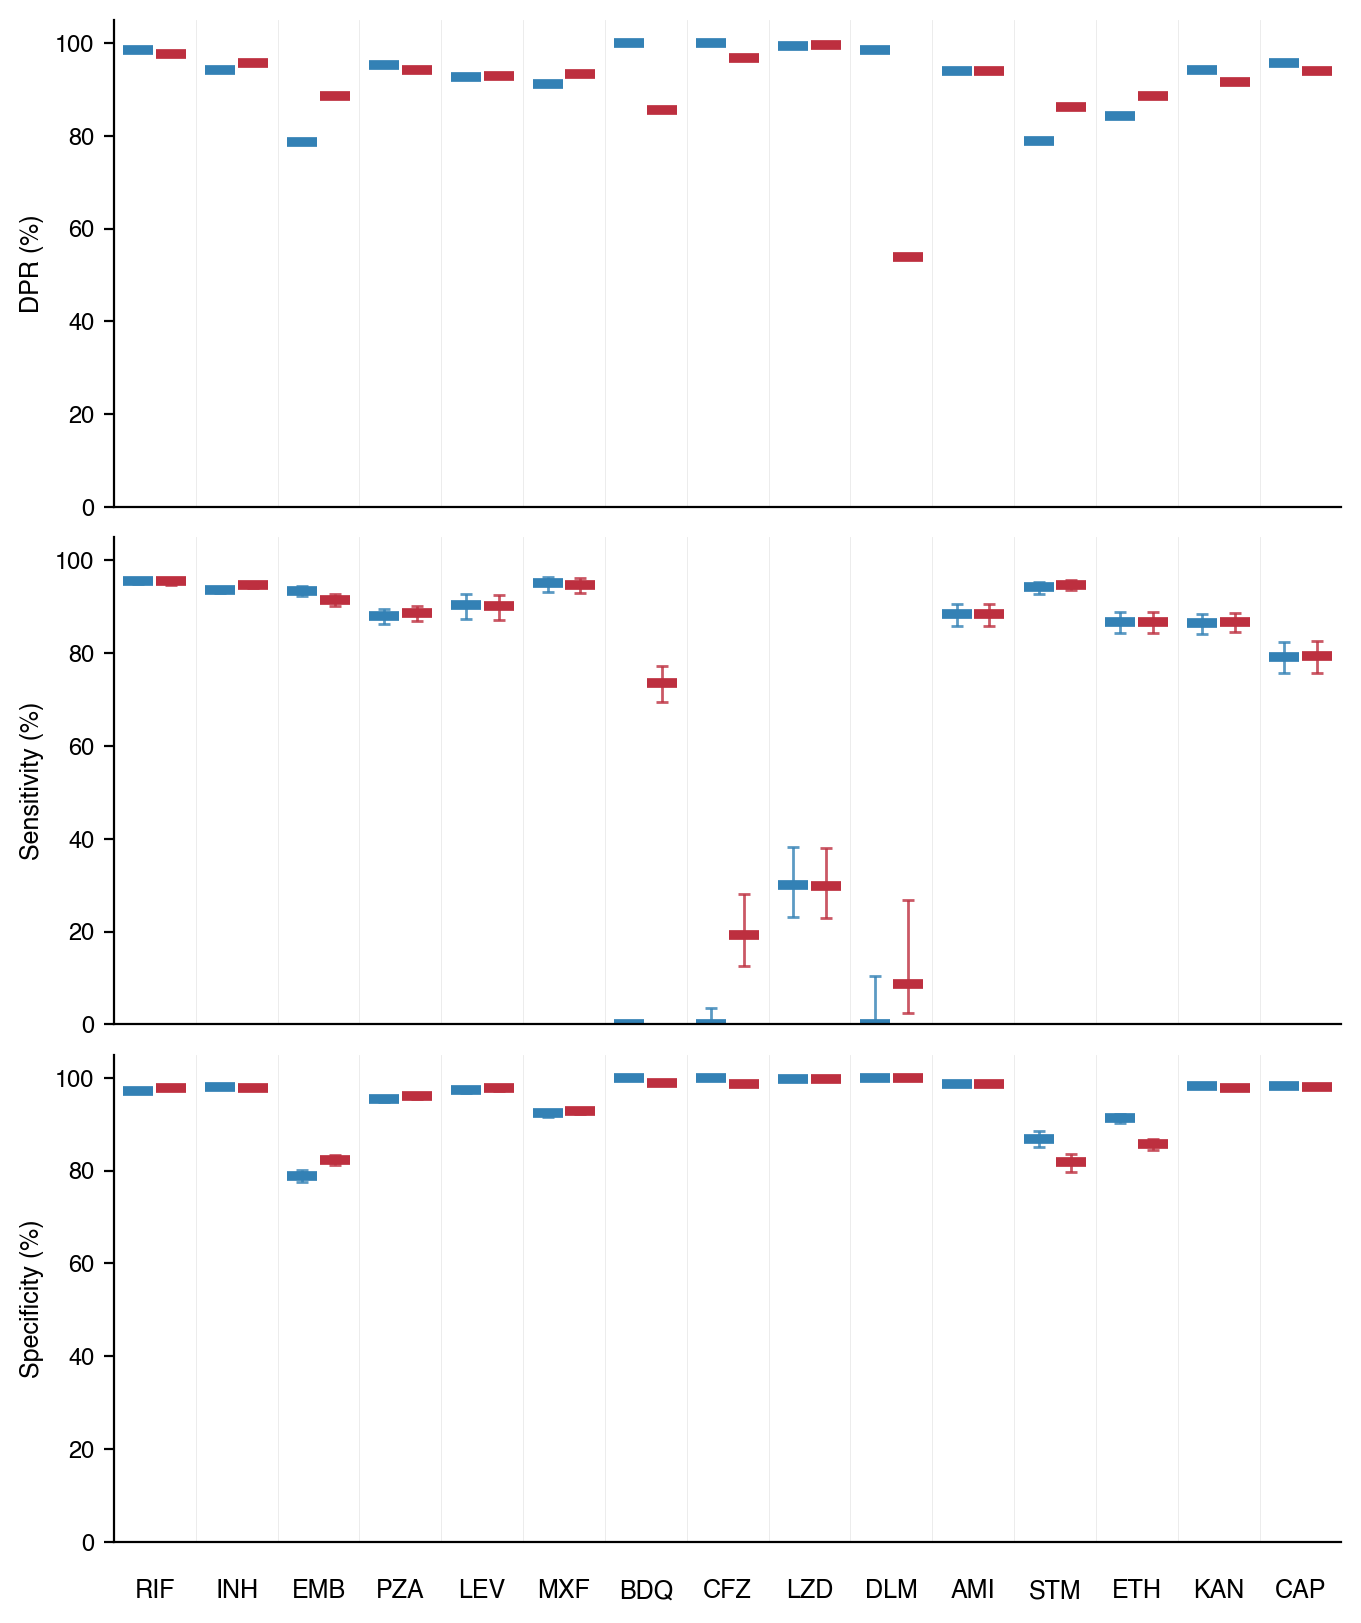

In [126]:
results_validation = pd.read_csv('results/performance/whov1_whov2_cat1_validation.csv')
results_validation.DRUG = results_validation.DRUG.astype('category')
results_validation.DRUG = results_validation.DRUG.cat.set_categories(who_drugs)
results_validation.sort_values(['DRUG','catalogue'], inplace=True, ascending=False)
results_validation = results_validation[results_validation.DRUG.isin(who_results.drug.values)]

graphs.plot_scatter_catomatic(results_validation[results_validation.catalogue.isin(['MTBC-CRyPTICv1.1.1-2025.8', 'WHOv1'])], 'figs/performance/scatter-validation-who1-cat1.pdf', who_drugs, show_graph=True, figsize=(6.69, 8))

## WHOv1 (train) vs WHOv1 (val) & WHOv2 (train) vs WHOv2 (val)

Already generated results, just in different tables, so can combine and calculate p values 

In [127]:
#generate p values for WHOv1 on training set vs WHOv1 on validation set (and the same for whov2)
catalogues = ['WHOv1', 'WHOv2']

metric_funcs = {
    'sens_p_value': lambda r: (r['TP'], r['TP'] + r['FN']),
    'spec_p_value': lambda r: (r['TN'], r['TN'] + r['FP']),
    'dpr_p_value': lambda r: (r['TP'] + r['TN'] + r['FP'] + r['FN'], 
                              r['TP'] + r['TN'] + r['FP'] + r['FN'] + r['UP'] + r['UN']),
    'sens2_p_value': lambda r: (r['TP'], r['TP'] + r['FN'] + r['UP']),
    'spec2_p_value': lambda r: (r['TN'] + r['UN'], r['TN'] + r['FP'] + r['UN'])
}

results = []

for drug in results_train['DRUG'].unique():
    for cat in catalogues:
        g_train = results_train[(results_train['DRUG'] == drug) & (results_train['catalogue'] == cat)].iloc[0]
        g_valid = results_val[(results_val['DRUG'] == drug) & (results_val['catalogue'] == cat)].iloc[0]
        row = {'DRUG': drug, 'Comparison': f'{cat} (train > valid)'}
        for col_name, fn in metric_funcs.items():
            c1, n1 = fn(g_train)
            c2, n2 = fn(g_valid)
            stat, pval = proportions_ztest([c1, c2], [n1, n2], alternative='larger')
            row[col_name] = pval
        results.append(row)

df_train_vs_valid_pvals = pd.DataFrame(results)
df_train_vs_valid_pvals[df_train_vs_valid_pvals.sens_p_value<0.05]

/Users/dylanadlard/miniforge3/envs/cryptic-catalogues-25/lib/python3.13/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


,DRUG,Comparison,sens_p_value,spec_p_value,dpr_p_value,sens2_p_value,spec2_p_value
0,RIF,WHOv1 (train > valid),0.032244,3.060374e-02,9.999999e-01,0.023118,2.296920e-02
1,RIF,WHOv2 (train > valid),0.029697,3.148689e-02,9.999998e-01,0.033573,2.405644e-02
4,EMB,WHOv1 (train > valid),0.000042,3.073821e-108,2.973679e-37,0.000020,1.393764e-76
5,EMB,WHOv2 (train > valid),0.000111,9.030987e-112,1.012182e-60,0.004238,6.865579e-79
18,DLM,WHOv1 (train > valid),0.040520,8.158585e-01,2.164671e-02,0.030801,8.161835e-01
24,ETH,WHOv1 (train > valid),0.003336,9.924733e-01,2.145467e-03,0.101479,9.976677e-01
25,ETH,WHOv2 (train > valid),0.004795,9.313946e-01,2.857150e-02,0.280440,9.651547e-01


## WHOv1 without rules vs WHOv1 with rules vs catomaticv1

In [128]:
cat = pd.read_csv('catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv')

w_garc_path = 'catalogues/whov1/WHO-UCN-GTB-PCI-2021.7-eng_w_GARC.xlsx'
#flag mutations that had expert rules applied to WHOv1
if not os.path.exists(w_garc_path):
    utils.generate_garc_mutations('catalogues/whov1/WHO-UCN-GTB-PCI-2021.7-eng.xlsx', 'data/NC_000962.3.gbk').to_excel(w_garc_path)

who_original = pd.read_excel(w_garc_path)

filtered = who_original[~who_original['Additional grading criteria'].isna()]

prediction_map = {
    'Assoc w R': 'R',
    'Assoc w R - Interim': 'R',
    'Uncertain significance': 'U',
    'Not assoc w R': 'S',
    'Not assoc w R - Interim': 'S'
}
filtered['PREDICTION'] = filtered['INITIAL CONFIDENCE GRADING'].map(prediction_map)
mapping = dict(zip(filtered['GARC_MUTATION'], filtered['PREDICTION']))
normalized_order = {
    '&'.join(sorted(key.split('&'))): val
    for key, val in mapping.items()
}
def normalize_order(mutation_str):
    return '&'.join(sorted(mutation_str.split('&')))

cat_no_rules = cat[(~cat['MUTATION'].str.contains('indel'))]
mask = cat_no_rules["MUTATION"].str.contains(r"[*?=]", regex=True)
cat_no_rules.loc[mask & (cat_no_rules["PREDICTION"] == "R"), "PREDICTION"] = "U"

cat_no_rules['PREDICTION'] = cat_no_rules.apply(
    lambda row: normalized_order.get(normalize_order(row['MUTATION']), row['PREDICTION']),
    axis=1
)
cat_no_rules['PREDICTION'] = cat_no_rules['PREDICTION'].fillna('U')
cat_no_rules.to_csv('./catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS_no_rules.csv')

/var/folders/s5/pshvb2093574r5hqnwcy6klw0000gn/T/ipykernel_30610/1780233048.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['PREDICTION'] = filtered['INITIAL CONFIDENCE GRADING'].map(prediction_map)
/var/folders/s5/pshvb2093574r5hqnwcy6klw0000gn/T/ipykernel_30610/1780233048.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cat_no_rules['PREDICTION'] = cat_no_rules.apply(
/var/folders/s5/pshvb2093574r5hqnwcy6klw0000gn/T/ipykernel_30610/1780233048.py:36: SettingWithCopyWarning: 
A value is tr

In [129]:
if run_long_processes:

    catalogues = {
        'WHOv1_no_rules': 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS_no_rules.csv',
        'WHOv1': 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv',
        'MTBC-CRyPTICv1.1.1-2025.8': "catalogues/MTBC-CRyPTICv1.1.1-2025.8.csv",
    }

    results_val_no_rules = parallel_performance_evaluation(drug_genes, catalogues, validation=True, frs=0.1)
    results_val_no_rules.to_csv('results/performance/whov1_no_rules_whov1_cat1_validation.csv')
results_val_no_rules = pd.read_csv('results/performance/whov1_no_rules_whov1_cat1_validation.csv')
results_val_no_rules[:6]

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,SENSITIVITY_LOW,SENSITIVITY_HIGH,SPECIFICITY_LOW,SPECIFICITY_HIGH,DPR_LOW,DPR_HIGH,TP,FN,TN,FP,UP,UN
0,0,RIF,WHOv1_no_rules,0.954073,0.979390,0.968821,0.921550,0.979997,0.947262,0.960041,0.975786,0.982468,0.965482,0.971846,3947,190,6843,144,146,212
1,1,RIF,WHOv1,0.955504,0.971052,0.985630,0.952603,0.971663,0.948899,0.961289,0.966873,0.974717,0.983285,0.987650,4080,190,6843,204,13,152
2,2,RIF,MTBC-CRyPTICv1.1.1-2025.8,0.954480,0.978878,0.975701,0.935092,0.979442,0.947747,0.960382,0.975240,0.981992,0.972722,0.978362,4005,191,6859,148,87,192
3,3,INH,WHOv1_no_rules,0.935825,0.980231,0.934974,0.881914,0.981641,0.928634,0.942336,0.976286,0.983530,0.930295,0.939359,4608,316,5603,113,301,439
4,4,INH,WHOv1,0.936610,0.979374,0.940773,0.893589,0.980829,0.929504,0.943043,0.975357,0.982748,0.936286,0.944963,4669,316,5603,118,240,434
5,5,INH,MTBC-CRyPTICv1.1.1-2025.8,0.945935,0.976962,0.957030,0.910813,0.978067,0.939339,0.951851,0.972797,0.980503,0.953147,0.960604,4759,272,5725,135,194,295


In [130]:
#generate p values for whov1 vs whov2 vs catomatic
pvals_val_no_rules = utils.generate_pvals(results_val_no_rules, comparisons=[('MTBC-CRyPTICv1.1.1-2025.8', 'WHOv1_no_rules'), ('MTBC-CRyPTICv1.1.1-2025.8', 'WHOv1'), ('WHOv1', 'WHOv1_no_rules')])
pvals_val_no_rules.to_csv('results/performance/p_vals_whov1_whov1_no_rules_cat1_validation.csv')
pvals_val_no_rules[:10]

/Users/dylanadlard/miniforge3/envs/cryptic-catalogues-25/lib/python3.13/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


,DRUG,Comparison,sens_p_value,spec_p_value,dpr_p_value,sens2_p_value,spec2_p_value
0,RIF,MTBC-CRyPTICv1.1.1-2025.8 > WHOv1_no_rules,0.929057,0.832198,1.501303e-03,1.512486e-02,0.813050
1,RIF,MTBC-CRyPTICv1.1.1-2025.8 > WHOv1,0.820407,0.002989,4.674336e-08,4.316116e-04,0.002511
2,RIF,WHOv1 > WHOv1_no_rules,0.752271,0.001492,1.376614e-17,3.260230e-09,0.001130
3,INH,MTBC-CRyPTICv1.1.1-2025.8 > WHOv1_no_rules,0.032401,0.224643,1.821904e-13,1.257124e-06,0.158159
4,INH,MTBC-CRyPTICv1.1.1-2025.8 > WHOv1,0.047137,0.374711,2.563173e-08,3.037544e-03,0.280171
5,INH,WHOv1 > WHOv1_no_rules,0.872922,0.744699,6.992889e-02,5.871525e-02,0.739809
6,EMB,MTBC-CRyPTICv1.1.1-2025.8 > WHOv1_no_rules,0.020778,0.000056,8.701592e-58,4.857585e-01,0.761242
7,EMB,MTBC-CRyPTICv1.1.1-2025.8 > WHOv1,0.020778,0.000056,8.701592e-58,4.857585e-01,0.761242
8,EMB,WHOv1 > WHOv1_no_rules,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000
9,PZA,MTBC-CRyPTICv1.1.1-2025.8 > WHOv1_no_rules,0.026102,0.004164,3.616998e-15,4.281448e-20,0.003813


In [131]:
diffs = utils.compute_metric_differences(results_val_no_rules, pvals_val_no_rules)
diffs = pd.merge(diffs, pvals_val_no_rules, on=['DRUG', 'Comparison'])
diffs[['DRUG', 'Comparison', 'SENSITIVITY_diff', 'sens_p_value', 'SPECIFICITY_diff', 'spec_p_value', 'COVERAGE_diff', 'dpr_p_value']][:10]

,DRUG,Comparison,SENSITIVITY_diff,sens_p_value,SPECIFICITY_diff,spec_p_value,COVERAGE_diff,dpr_p_value
0,RIF,MTBC-CRyPTICv1.1.1-2025.8 > WHOv1_no_rules,0.000407,0.929057,-0.000512,0.832198,0.006880,1.501303e-03
1,RIF,MTBC-CRyPTICv1.1.1-2025.8 > WHOv1,-0.001023,0.820407,0.007827,0.002989,-0.009929,4.674336e-08
2,RIF,WHOv1 > WHOv1_no_rules,0.001431,0.752271,-0.008339,0.001492,0.016809,1.376614e-17
3,INH,MTBC-CRyPTICv1.1.1-2025.8 > WHOv1_no_rules,0.010111,0.032401,-0.003268,0.224643,0.022056,1.821904e-13
4,INH,MTBC-CRyPTICv1.1.1-2025.8 > WHOv1,0.009325,0.047137,-0.002412,0.374711,0.016257,2.563173e-08
5,INH,WHOv1 > WHOv1_no_rules,0.000785,0.872922,-0.000857,0.744699,0.005800,6.992889e-02
6,EMB,MTBC-CRyPTICv1.1.1-2025.8 > WHOv1_no_rules,-0.020009,0.020778,0.035571,0.000056,0.099915,8.701592e-58
7,EMB,MTBC-CRyPTICv1.1.1-2025.8 > WHOv1,-0.020009,0.020778,0.035571,0.000056,0.099915,8.701592e-58
8,EMB,WHOv1 > WHOv1_no_rules,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000e+00
9,PZA,MTBC-CRyPTICv1.1.1-2025.8 > WHOv1_no_rules,0.027011,0.026102,-0.010454,0.004164,0.035254,3.616998e-15


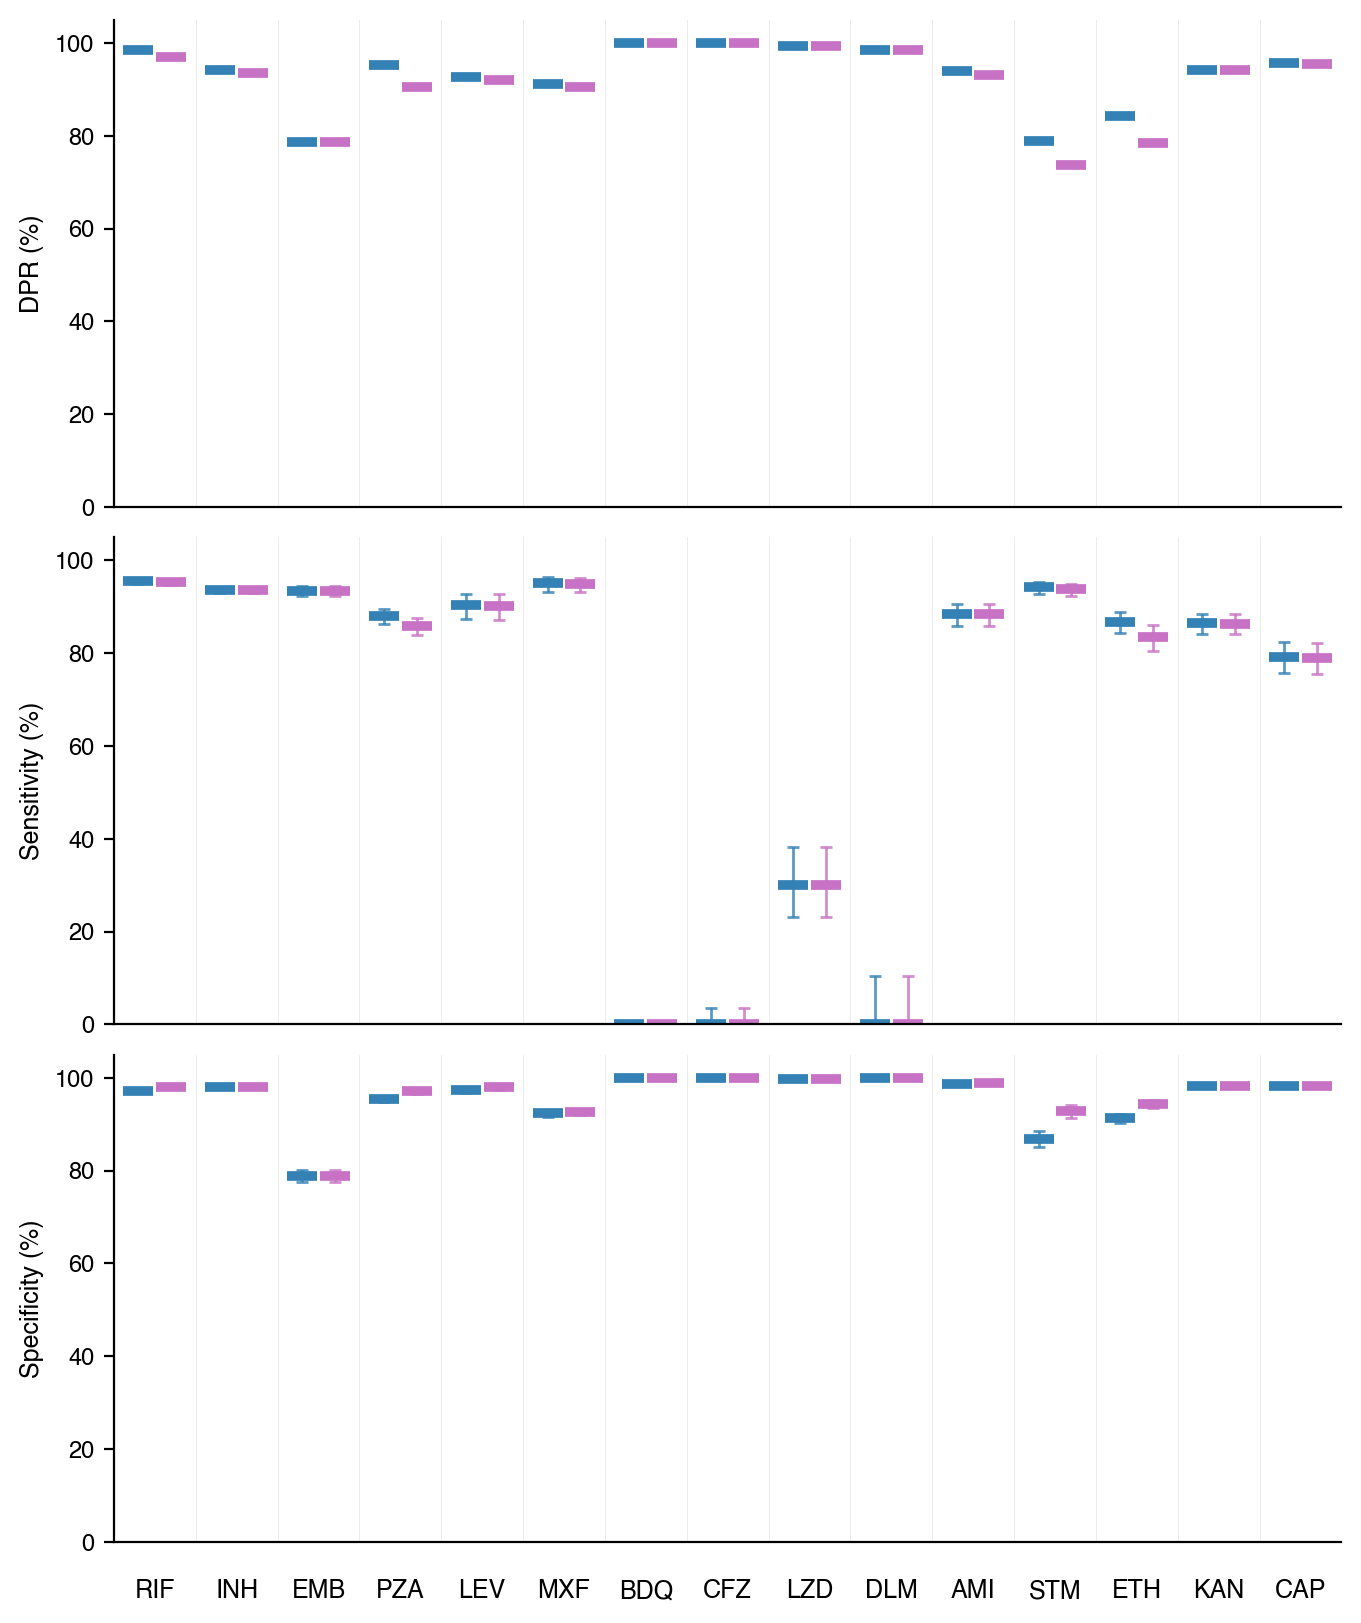

In [132]:
results_val_no_rules = pd.read_csv('results/performance/whov1_no_rules_whov1_cat1_validation.csv')
results_val_no_rules.DRUG = results_val_no_rules.DRUG.astype('category')
results_val_no_rules.DRUG = results_val_no_rules.DRUG.cat.set_categories(who_drugs)
results_val_no_rules.sort_values(['DRUG','catalogue'], inplace=True, ascending=False)
results_val_no_rules = results_val_no_rules.iloc[::-1]
results_val_no_rules = results_val_no_rules[results_val_no_rules.DRUG.isin(who_results.drug.values)]

graphs.plot_scatter_catomatic(results_val_no_rules[results_val_no_rules.catalogue.isin(['WHOv1', 'WHOv1_no_rules'])], 'figs/performance/scatter-validation-who1-who1_no_rules.pdf', who_drugs, show_graph=True, figsize=(6.69, 8))

## catomatic-1 vs catomatic-2 vs WHOv1 vs WHOv2 applied to all samples

In [133]:
#performance of catalogue trained on samples, applied to all samples (+catomatic trained on training samples applied to all data)
if run_long_processes:

    catalogues = {
        'MTBC-CRyPTICv1.1.1-2025.8': "catalogues/MTBC-CRyPTICv1.1.1-2025.8.csv",
        'MTBC-CRyPTICv3.4.0-2025.8': "catalogues/MTBC-CRyPTICv3.4.0-2025.8.csv",
        'WHOv1': 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv',
        'WHOv2': 'catalogues/whov2/NC_000962.3_WHO-UCN-TB-2023.5_v2.0_GARC1_RFUS.csv',
    }

    results_all = parallel_performance_evaluation(drug_genes, catalogues, validation=False,  dataset='all', frs=0.1)
    results_all.to_csv('results/performance/cat_all_samples.csv')
results_all = pd.read_csv('results/performance/cat_all_samples.csv')
results_all[:6]

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,SENSITIVITY_LOW,SENSITIVITY_HIGH,SPECIFICITY_LOW,SPECIFICITY_HIGH,DPR_LOW,DPR_HIGH,TP,FN,TN,FP,UP,UN
0,0,RIF,MTBC-CRyPTICv1.1.1-2025.8,0.959467,0.983877,0.972206,0.941490,0.984392,0.956183,0.962514,0.982442,0.985196,0.970704,0.973632,14321,605,31671,519,285,1062
1,1,RIF,MTBC-CRyPTICv3.4.0-2025.8,0.959516,0.983928,0.974702,0.942673,0.984392,0.956236,0.962559,0.982498,0.985244,0.973266,0.976063,14339,605,31774,519,267,959
2,2,RIF,WHOv1,0.960192,0.974179,0.979551,0.957794,0.974919,0.956963,0.963189,0.972392,0.975853,0.978253,0.980774,14569,604,31465,834,38,953
3,3,RIF,WHOv2,0.960519,0.974078,0.977736,0.958057,0.974889,0.957302,0.963503,0.972285,0.975758,0.976384,0.979012,14573,599,31377,835,39,1040
4,4,INH,MTBC-CRyPTICv1.1.1-2025.8,0.945644,0.985620,0.956984,0.915603,0.986342,0.942264,0.948838,0.984162,0.986946,0.955143,0.958753,17293,994,27760,405,600,1488
5,5,INH,MTBC-CRyPTICv3.4.0-2025.8,0.946292,0.985017,0.961145,0.926351,0.985769,0.942949,0.949450,0.983530,0.986371,0.959389,0.962828,17496,993,27743,422,398,1488


In [134]:
#generate p values for whov1 vs whov2 vs catomatic
pvals_val_all = utils.generate_pvals(results_all, comparisons=[('MTBC-CRyPTICv1.1.1-2025.8', 'MTBC-CRyPTICv3.4.0-2025.8')])
pvals_val_all.to_csv('results/performance/p_vals_all_samples.csv')
pvals_val_all[(pvals_val_all.Comparison=='MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0-2025.8')][:10]

,DRUG,Comparison,sens_p_value,spec_p_value,dpr_p_value,sens2_p_value,spec2_p_value
0,RIF,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.982927,0.958623,1.561767e-02,6.586342e-01,1.000000
1,INH,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.783465,0.551485,1.067890e-03,1.080881e-04,0.551634
2,EMB,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.249893,0.000361,3.754044e-05,9.339069e-09,0.000195
3,PZA,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.544618,0.047436,4.376210e-09,1.004790e-05,0.040741
4,LEV,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.986801,0.659535,5.067053e-01,8.633338e-01,0.686120
5,MXF,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.929845,0.842201,4.570754e-03,9.360323e-01,1.000000
6,BDQ,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.000004,0.000093,1.669544e-20,3.909272e-46,0.000076
7,LZD,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.933485,0.981468,8.378170e-10,9.335264e-01,1.000000
8,CFZ,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.479402,0.000290,2.573027e-02,3.876931e-01,0.000249
9,DLM,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.556169,0.405575,9.102993e-01,4.324894e-01,0.405264


In [135]:
utils.compute_metric_differences(results_all, pvals_val_all)[:10]

,DRUG,Comparison,SENSITIVITY_diff,SPECIFICITY_diff,COVERAGE_diff,SENSITIVITY2_diff,SPECIFICITY2_diff
0,RIF,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,-0.000049,-0.000051,-0.002497,-0.001183,0.000000
1,INH,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,-0.000648,0.000604,-0.004162,-0.010748,0.000573
2,EMB,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,-0.004562,0.008570,-0.008233,-0.030167,0.008122
3,PZA,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,-0.004085,0.003228,-0.008132,-0.031482,0.003237
4,LEV,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.000126,-0.000936,-0.001905,0.001505,-0.000796
5,MXF,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.000480,-0.000492,-0.006302,-0.000525,0.000000
6,BDQ,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,-0.102913,0.005274,-0.024710,-0.315682,0.005083
7,LZD,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,-0.002924,0.000012,0.004884,-0.002915,0.000000
8,CFZ,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,0.016887,-0.004302,0.004716,0.019749,-0.004185
9,DLM,MTBC-CRyPTICv1.1.1-2025.8 > MTBC-CRyPTICv3.4.0...,-0.035526,0.000382,-0.000677,-0.031414,0.000229


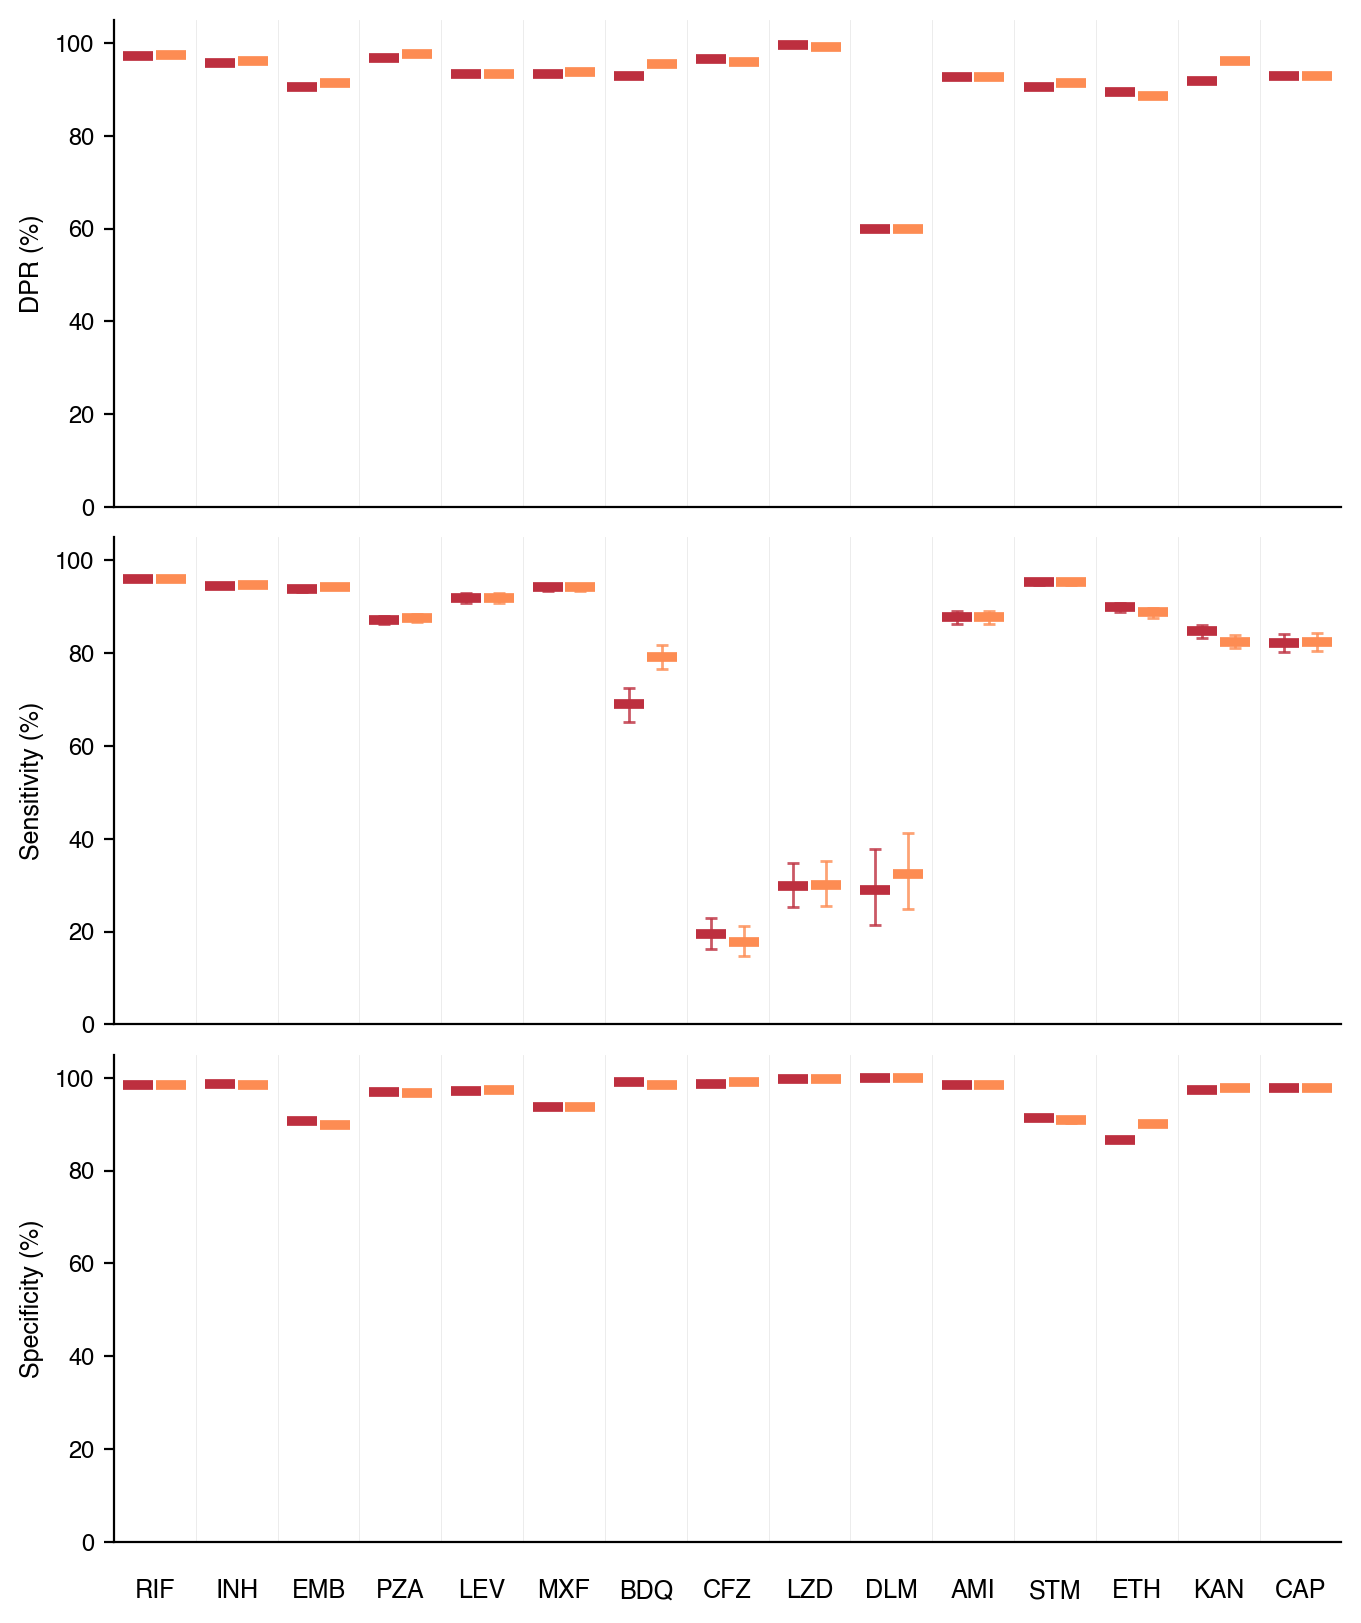

In [136]:
results_all_samples = pd.read_csv('results/performance/cat_all_samples.csv')
results_all_samples.DRUG = results_all_samples.DRUG.astype('category')
results_all_samples.DRUG = results_all_samples.DRUG.cat.set_categories(who_drugs)
results_all_samples.sort_values(['DRUG','catalogue'], ascending=False, inplace=True)
results_all_samples = results_all_samples.iloc[::-1]
results_all_samples[:6]

graphs.plot_scatter_catomatic(results_all_samples[results_all_samples.catalogue.isin(['MTBC-CRyPTICv1.1.1-2025.8', 'MTBC-CRyPTICv3.4.0-2025.8'])], 'figs/performance/scatter-cat1-cat2.pdf', who_drugs, show_graph=True, figsize=(6.69, 8))

#  Results tables

Tables for manuscript

In [137]:
results_val_no_rules = pd.read_csv('results/performance/whov1_no_rules_whov1_cat1_validation.csv')
results_val_no_rules.DRUG = results_val_no_rules.DRUG.astype('category')
results_val_no_rules.DRUG = results_val_no_rules.DRUG.cat.set_categories(who_drugs)
results_val_no_rules.sort_values(['DRUG','catalogue'], inplace=True, ascending=False)
results_val_no_rules = results_val_no_rules.iloc[::-1]
results_val_no_rules = results_val_no_rules[results_val_no_rules.DRUG.isin(who_results.drug.values)]

df = results_val_no_rules.copy()
df = df[["DRUG", "catalogue", "SENSITIVITY", "SPECIFICITY", "COVERAGE"]]
df_pivot = df.pivot(index="DRUG", columns="catalogue", values=["SENSITIVITY", "SPECIFICITY", "COVERAGE"])
df_pivot.columns = [f"{cat}_{metric}" for metric, cat in df_pivot.columns]
df_pivot = df_pivot.reset_index()
df_pivot

,DRUG,MTBC-CRyPTICv1.1.1-2025.8_SENSITIVITY,WHOv1_SENSITIVITY,WHOv1_no_rules_SENSITIVITY,MTBC-CRyPTICv1.1.1-2025.8_SPECIFICITY,WHOv1_SPECIFICITY,WHOv1_no_rules_SPECIFICITY,MTBC-CRyPTICv1.1.1-2025.8_COVERAGE,WHOv1_COVERAGE,WHOv1_no_rules_COVERAGE
0,INH,0.945935,0.936610,0.935825,0.976962,0.979374,0.980231,0.957030,0.940773,0.934974
1,RIF,0.954480,0.955504,0.954073,0.978878,0.971052,0.979390,0.975701,0.985630,0.968821
2,PZA,0.886420,0.879852,0.859409,0.960199,0.953707,0.970653,0.940818,0.951579,0.905564
3,EMB,0.914621,0.934630,0.934630,0.823516,0.787945,0.787945,0.886441,0.786526,0.786526
4,BDQ,0.736196,0.000000,0.000000,0.988437,1.000000,1.000000,0.855123,1.000000,1.000000
5,LZD,0.299270,0.301471,0.301471,0.996985,0.996977,0.996977,0.995525,0.992840,0.992840
6,MXF,0.947704,0.950192,0.949351,0.927906,0.923464,0.927306,0.931938,0.910331,0.904659
7,LEV,0.901826,0.904328,0.902552,0.977199,0.973866,0.979912,0.929173,0.927141,0.919884
8,CFZ,0.191919,0.000000,0.000000,0.987214,1.000000,1.000000,0.966499,1.000000,1.000000
9,DLM,0.086957,0.000000,0.000000,1.000000,1.000000,1.000000,0.538652,0.984116,0.984116


In [138]:
results_all = pd.read_csv('results/performance/cat_all_samples.csv')
results_all.DRUG = results_all.DRUG.astype('category')
results_all.DRUG = results_all.DRUG.cat.set_categories(who_drugs)
results_all.sort_values(['DRUG','catalogue'], inplace=True, ascending=False)
results_all = results_all.iloc[::-1]
results_all = results_all[results_all.DRUG.isin(who_results.drug.values)]

df = results_all.copy()
df = df[["DRUG", "catalogue", "SENSITIVITY", "SPECIFICITY", "COVERAGE"]]
df_pivot = df.pivot(index="DRUG", columns="catalogue", values=["SENSITIVITY", "SPECIFICITY", "COVERAGE"])
df_pivot.columns = [f"{cat}_{metric}" for metric, cat in df_pivot.columns]
df_pivot = df_pivot.reset_index()
df_pivot

,DRUG,MTBC-CRyPTICv1.1.1-2025.8_SENSITIVITY,MTBC-CRyPTICv3.4.0-2025.8_SENSITIVITY,WHOv1_SENSITIVITY,WHOv2_SENSITIVITY,MTBC-CRyPTICv1.1.1-2025.8_SPECIFICITY,MTBC-CRyPTICv3.4.0-2025.8_SPECIFICITY,WHOv1_SPECIFICITY,WHOv2_SPECIFICITY,MTBC-CRyPTICv1.1.1-2025.8_COVERAGE,MTBC-CRyPTICv3.4.0-2025.8_COVERAGE,WHOv1_COVERAGE,WHOv2_COVERAGE
0,INH,0.945644,0.946292,0.935213,0.942154,0.985620,0.985017,0.987193,0.986083,0.956984,0.961145,0.953379,0.947590
1,RIF,0.959467,0.959516,0.960192,0.960519,0.983877,0.983928,0.974179,0.974078,0.972206,0.974702,0.979551,0.977736
2,PZA,0.871548,0.875633,0.863187,0.865477,0.969990,0.966762,0.968040,0.969606,0.967505,0.975638,0.974109,0.979739
3,EMB,0.938530,0.943092,0.951458,0.934306,0.906123,0.897554,0.892758,0.902203,0.904721,0.912953,0.837438,0.871452
4,BDQ,0.689600,0.792513,0.000000,0.754177,0.989865,0.984591,1.000000,0.984212,0.929151,0.953861,1.000000,0.962870
5,LZD,0.298246,0.301170,0.299120,0.299120,0.997692,0.997681,0.997681,0.997681,0.996377,0.991493,0.991440,0.991440
6,MXF,0.942167,0.941687,0.942966,0.942795,0.936840,0.937332,0.932308,0.931858,0.931897,0.938199,0.911323,0.923968
7,LEV,0.919563,0.919437,0.920157,0.920715,0.972552,0.973488,0.969960,0.968458,0.931866,0.933771,0.924639,0.927267
8,CFZ,0.194030,0.177143,0.000000,0.157895,0.987047,0.991349,1.000000,0.985688,0.964413,0.959696,1.000000,0.964413
9,DLM,0.289474,0.325000,0.068323,0.147727,0.999363,0.998981,0.999769,0.999537,0.599278,0.599955,0.987811,0.989166
